# 04 - Comparación con labels reales

Objetivo: comparar las predicciones de los modelos entrenados con parches contra los labels reales de las imágenes de test, para validar que el modelo funciona bien en imágenes nuevas y decidir qué modelo usar para la inferencia.

In [2]:
from pathlib import Path

# Rutas original
ruta_test_original = Path("/home/salvarado/TFM/Dataset_preparados/dataset_kanji_prep/dataset_original/images/test")
ruta_labels_original = Path("/home/salvarado/TFM/Dataset_preparados/dataset_kanji_prep/dataset_original/labels/test")
ruta_modelo_original = "/home/salvarado/TFM/resultados/result_yolo/parches_originales_1024_50ep-2/weights/best.pt"

# Rutas denoised
ruta_test_denoised = Path("/home/salvarado/TFM/Dataset_preparados/dataset_kanji_prep/dataset_denoised/images/test")
ruta_labels_denoised = Path("/home/salvarado/TFM/Dataset_preparados/dataset_kanji_prep/dataset_denoised/labels/test")
ruta_modelo_denoised = "/home/salvarado/TFM/resultados/result_yolo/parches_denoised_1024_50ep/weights/best.pt"

print("Rutas definidas")

Rutas definidas


In [3]:
print("Original:")
print(" imágenes:", ruta_test_original.exists())
print(" labels:", ruta_labels_original.exists())

print("\nDenoised:")
print(" imágenes:", ruta_test_denoised.exists())
print(" labels:", ruta_labels_denoised.exists())

Original:
 imágenes: True
 labels: True

Denoised:
 imágenes: True
 labels: True


## Contar kanjis reales de lols labels

Se cuenta el número de kanjis anotados en cada imagen de test a partir de los labels reales.

In [4]:
import os

print("Kanjis reales por imagen (original):")
print()
for nombre in sorted(os.listdir(ruta_labels_original)):
    if not nombre.endswith(".txt"):
        continue
    with open(ruta_labels_original / nombre, "r") as f:
        lines = f.readlines()
    print(f"{nombre.replace('.txt', '')}: {len(lines)} kanjis")

Kanjis reales por imagen (original):

sakuma-0447_Page_02: 152 kanjis
sakuma-0451_Page_26: 323 kanjis
sakuma-0469_Page_09: 259 kanjis
sakuma-0469_Page_13: 229 kanjis
sakuma-0470_Page_07: 260 kanjis
sakuma-0513_Page_03: 100 kanjis
sakuma-0513_Page_06: 321 kanjis
sakuma-0581_Page_12: 237 kanjis
sakuma-0581_Page_19: 250 kanjis
sakuma-0581_Page_29: 129 kanjis


## Evaluación mediante solapamiento (IoU) con el ground truth

A diferencia del conteo simple de detecciones, en esta sección se evalúa si cada detección del modelo coincide realmente en posición con un kanji real, mediante el cálculo del Intersection over Union (IoU) entre cada caja detectada y las cajas del ground truth.

Para cada imagen se obtienen tres valores:

- **TP (verdaderos positivos):** detecciones que solapan con una caja real por encima del umbral establecido (IoU ≥ 0,5).
- **FP (falsos positivos):** detecciones que no solapan con ninguna caja real.
- **FN (falsos negativos):** kanjis reales que no fueron cubiertos por ninguna detección.

A partir de estos valores se calculan las métricas de precisión y recall, consistentes con las empleadas en el resto de la evaluación de este trabajo (apartado 3.2):

- Precisión = TP / (TP + FP)
- Recall = TP / (TP + FN)

Cada detección se empareja como máximo con una única caja real (la de mayor IoU disponible en ese momento), evitando que una misma caja real cuente como acierto múltiples veces.

In [5]:
def calcular_iou(caja1, caja2):
    """Calcula el IoU entre dos cajas [x1, y1, x2, y2]."""
    x1 = max(caja1[0], caja2[0])
    y1 = max(caja1[1], caja2[1])
    x2 = min(caja1[2], caja2[2])
    y2 = min(caja1[3], caja2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    interseccion = inter_w * inter_h

    area1 = (caja1[2] - caja1[0]) * (caja1[3] - caja1[1])
    area2 = (caja2[2] - caja2[0]) * (caja2[3] - caja2[1])
    union = area1 + area2 - interseccion

    return interseccion / union if union > 0 else 0


def evaluar_deteccion(reales, detectadas, umbral_iou=0.5):
    """
    Empareja detecciones con cajas reales por IoU.
    reales, detectadas: listas de [x1, y1, x2, y2]
    Devuelve: TP, FP, FN
    """
    reales_usadas = [False] * len(reales)
    tp = 0
    fp = 0

    for caja_det in detectadas:
        mejor_iou = 0
        mejor_idx = -1
        for i, caja_real in enumerate(reales):
            if reales_usadas[i]:
                continue
            iou = calcular_iou(caja_det, caja_real)
            if iou > mejor_iou:
                mejor_iou = iou
                mejor_idx = i

        if mejor_iou >= umbral_iou:
            tp += 1
            reales_usadas[mejor_idx] = True
        else:
            fp += 1

    fn = reales_usadas.count(False)
    return tp, fp, fn

print("Funciones de evaluación por IoU cargadas")

Funciones de evaluación por IoU cargadas


## Predicción y evaluación del modelo original sobre imágenes completas

En esta sección se aplica el modelo YOLO entrenado con parches directamente sobre las páginas completas de test, sin utilizar el pipeline de división en parches. Para cada imagen, las detecciones obtenidas se evalúan frente al ground truth mediante el criterio de solapamiento (IoU) definido anteriormente, calculando el número de verdaderos positivos, falsos positivos y falsos negativos, así como la precisión y el recall resultantes.

In [8]:
from ultralytics import YOLO
import os
import cv2

model_original = YOLO(ruta_modelo_original)

print("Evaluación por IoU - modelo original sobre imágenes completas:")
print()

resultados_tabla = []

for nombre in sorted(os.listdir(ruta_test_original)):
    if not nombre.endswith(".png"):
        continue

    img_path = str(ruta_test_original / nombre)
    label_path = str(ruta_labels_original / nombre.replace(".png", ".txt"))

    imagen = cv2.imread(img_path)
    alto, ancho = imagen.shape[:2]
    reales = []
    with open(label_path) as f:
        for linea in f:
            datos = linea.split()
            cx = float(datos[1]) * ancho
            cy = float(datos[2]) * alto
            bw = float(datos[3]) * ancho
            bh = float(datos[4]) * alto
            reales.append([cx - bw/2, cy - bh/2, cx + bw/2, cy + bh/2])

    results = model_original.predict(source=img_path, conf=0.5, imgsz=1024, device=0, verbose=False)
    detectadas = [box.xyxy[0].cpu().numpy().tolist() for box in results[0].boxes]

    tp, fp, fn = evaluar_deteccion(reales, detectadas, umbral_iou=0.5)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    nombre_limpio = nombre.replace(".png", "")
    resultados_tabla.append([nombre_limpio, len(reales), tp, fp, fn, round(precision, 3), round(recall, 3)])
    print(f"{nombre_limpio}: TP={tp}, FP={fp}, FN={fn}, Precisión={precision:.3f}, Recall={recall:.3f}")

Evaluación por IoU - modelo original sobre imágenes completas:



sakuma-0447_Page_02: TP=119, FP=7, FN=33, Precisión=0.944, Recall=0.783
sakuma-0451_Page_26: TP=268, FP=22, FN=55, Precisión=0.924, Recall=0.830
sakuma-0469_Page_09: TP=198, FP=25, FN=61, Precisión=0.888, Recall=0.764
sakuma-0469_Page_13: TP=146, FP=19, FN=83, Precisión=0.885, Recall=0.638
sakuma-0470_Page_07: TP=220, FP=22, FN=40, Precisión=0.909, Recall=0.846
sakuma-0513_Page_03: TP=94, FP=0, FN=6, Precisión=1.000, Recall=0.940
sakuma-0513_Page_06: TP=218, FP=37, FN=103, Precisión=0.855, Recall=0.679
sakuma-0581_Page_12: TP=173, FP=26, FN=64, Precisión=0.869, Recall=0.730
sakuma-0581_Page_19: TP=156, FP=27, FN=94, Precisión=0.852, Recall=0.624
sakuma-0581_Page_29: TP=101, FP=12, FN=28, Precisión=0.894, Recall=0.783


## Análisis

Sin el pipeline de parches, el modelo detecta menos kanjis de los que hay realmente en todas las imágenes. Las diferencias van desde -6 hasta -67 kanjis, lo que indica un recall bajo al predecir sobre imágenes completas esto confirma que aunque el modelo fue entrenado con parches y obtuvo buenas métricas en validación, necesita el pipeline de parches también en inferencia para funcionar correctamente sobre imágenes completas nuevas.

## Visualización predicción sobre imagen completa

Se visualiza una imagen de test para ver cómo detecta el modelo directamente sobre la imagen completa, sin dividir en parches.

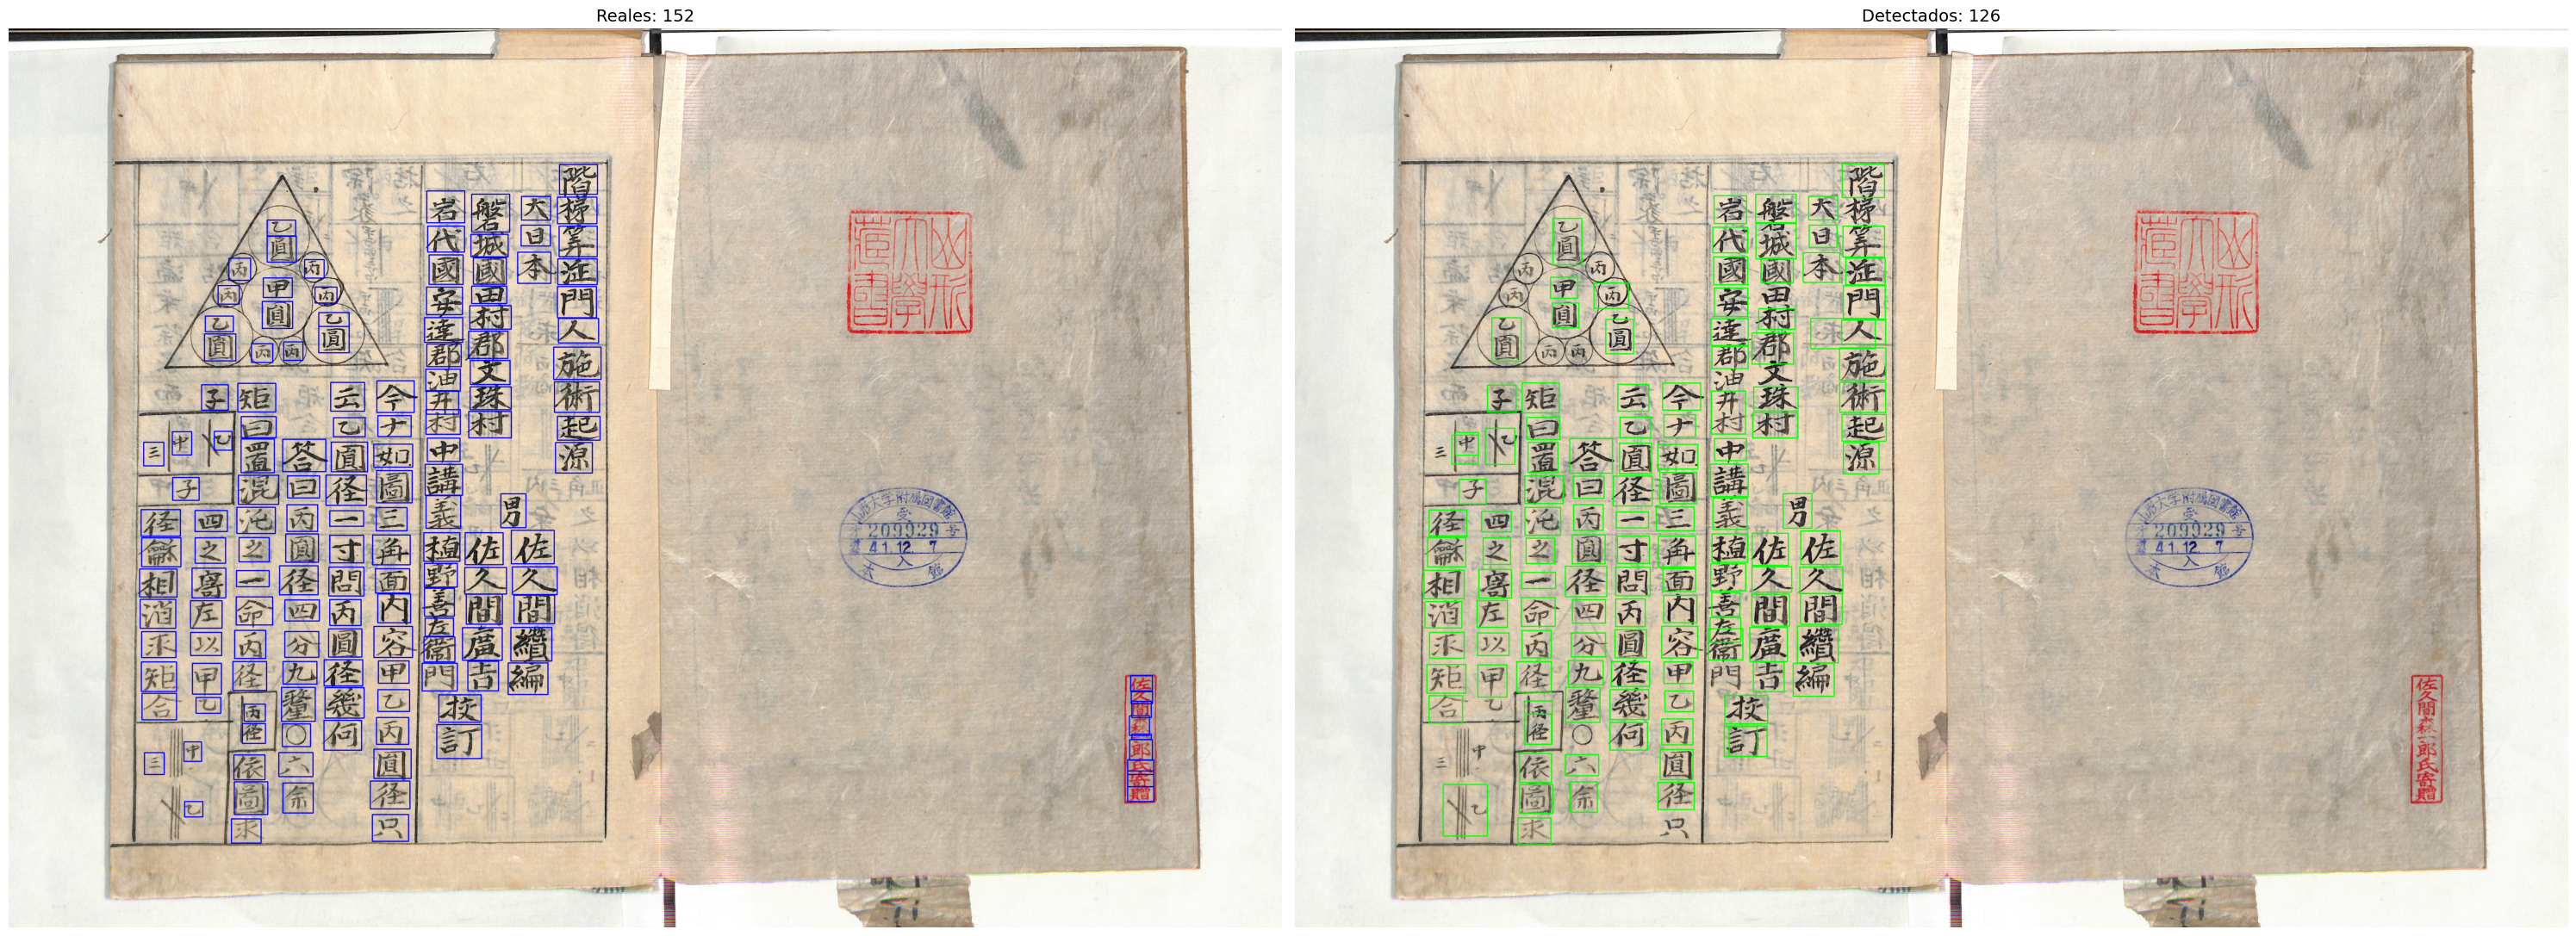

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2
import glob
import os

# Solo la primera imagen
img_path = sorted(glob.glob(str(ruta_test_original) + "/*.png"))[0]
imagen = cv2.imread(img_path)
nombre = os.path.basename(img_path).replace(".png","")

# Leer reales
label_path = str(ruta_labels_original / (nombre + ".txt"))
reales = []
with open(label_path) as f:
    for linea in f:
        datos = linea.split()
        alto, ancho = imagen.shape[:2]
        cx = float(datos[1]) * ancho
        cy = float(datos[2]) * alto
        bw = float(datos[3]) * ancho
        bh = float(datos[4]) * alto
        reales.append([int(cx-bw/2), int(cy-bh/2), int(cx+bw/2), int(cy+bh/2)])

# Predecir sobre imagen completa
results = model_original.predict(source=img_path, conf=0.5, imgsz=1024, device=0, verbose=False)

# Dibujar reales (azul) y detectados (verde)
img_reales = imagen.copy()
for x1,y1,x2,y2 in reales:
    cv2.rectangle(img_reales, (x1,y1), (x2,y2), (255,0,0), 8)

img_detect = imagen.copy()
for box in results[0].boxes:
    x1,y1,x2,y2 = box.xyxy[0].cpu().numpy().astype(int)
    cv2.rectangle(img_detect, (x1,y1), (x2,y2), (0,255,0), 8)

fig, axes = plt.subplots(1, 2, figsize=(30, 12))
axes[0].imshow(cv2.cvtColor(img_reales, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Reales: {len(reales)}", fontsize=14)
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(img_detect, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Detectados: {len(results[0].boxes)}", fontsize=14)
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Análisis

La comparación visual confirma lo que muestra la tabla numérica el modelo detecta menos kanjis de los reales al predecir directamente sobre la imagen completa,  Visualmente se aprecian zonas donde hay kanjis reales (azul) que el modelo no detecta (verde), especialmente en zonas con caracteres pequeños o muy juntos esto confirma que predecir directamente sobre la imagen completa no es suficiente y justifica implementar la inferencia con parches en el notebook siguiente.